# Laboratorio I – Series de Tiempo

Este cuaderno contiene el análisis de series de tiempo del ingreso mensual de viajeros internacionales a Guatemala entre enero de 2009 y junio de 2026. El objetivo es describir el comportamiento histórico del turismo receptor, construir series mensuales agregadas por distintas categorías, evaluar su estacionariedad y comparar varios modelos de pronóstico sobre un conjunto de prueba.

Como medida consistente en todo el periodo se emplea la suma de turistas y excursionistas, ya que la categoría viajero excluye desde 2023 a los viajeros no turísticos de alta frecuencia. Las categorías de análisis seleccionadas son la vía de ingreso y la región de residencia.

## Verificación de entorno

Confirma la versión de Python, la disponibilidad de los paquetes requeridos y la existencia del archivo de datos.

In [34]:
import sys, importlib
from pathlib import Path
print("Python:", sys.version.split()[0])
print("Ejecutable:", sys.executable)
paquetes = ["pandas","numpy","matplotlib","seaborn","scipy","statsmodels",
            "sklearn","pmdarima","prophet","pyarrow","openpyxl"]
for pkg in paquetes:
    try:
        m = importlib.import_module(pkg)
        print(f"OK  {pkg:12s} {getattr(m,'__version__','?')}")
    except Exception as e:
        print(f"FALTA {pkg:12s} {type(e).__name__}")
print("Existe Data.xlsx:", Path("../data/raw/Data.xlsx").exists())

Python: 3.12.0
Ejecutable: c:\Users\andre\Desktop\Lab1\.venv\Scripts\python.exe
OK  pandas       3.0.5
OK  numpy        2.5.1
OK  matplotlib   3.11.1
OK  seaborn      0.13.2
OK  scipy        1.18.0
OK  statsmodels  0.14.6
OK  sklearn      1.9.0
OK  pmdarima     2.1.1
OK  prophet      1.3.0
OK  pyarrow      25.0.0
OK  openpyxl     3.1.5
Existe Data.xlsx: True


## Carga y preparación de los datos

Lectura del archivo original, limpieza de espacios en las variables categóricas y construcción de la fecha mensual. El resultado se guarda como un archivo procesado reutilizable por el resto del cuaderno.

In [35]:
# ------------------------------------------------------------
# Carga del Excel, limpieza de texto y construcción de la fecha
# ------------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd

RAW = Path("../data/raw/Data.xlsx")
PROC = Path("../data/processed")
PROC.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(RAW, sheet_name="Datos")
print("Shape original:", df.shape)

# Se eliminan espacios sobrantes en las columnas categóricas
columnas_texto = ["Mes","Vía","Frontera","País","Región","Región dos",
                  "Regiones OMT","MCEO","Agrupación Residencia","Tipo de Viajero"]
for col in columnas_texto:
    df[col] = df[col].astype(str).str.strip()

# Fecha mensual a partir del año y el código de mes
df["fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

print("Rango temporal:", df["fecha"].min().date(), "a", df["fecha"].max().date())
print("Nulos:", int(df.isna().sum().sum()), "Duplicados:", int(df.duplicated().sum()))

df.to_parquet(PROC/"migracion_clean.parquet", index=False)
print("Dataset limpio guardado")
df.head()

Shape original: (161036, 13)
Rango temporal: 2009-01-01 a 2026-06-01
Nulos: 0 Duplicados: 0
Dataset limpio guardado


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


## Ejercicio 1 – Análisis exploratorio

Se examina el comportamiento temporal del número de viajeros, los países, regiones, vías y fronteras con mayor volumen acumulado, la presencia de valores faltantes, duplicados y atípicos, y las estadísticas descriptivas principales.

In [36]:
# ------------------------------------------------------------
# Configuración de gráficos y contador secuencial de figuras
# ------------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.3, "font.size":10})
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)

FIGN = 0
FIG_INDEX = []

# Numera cada figura de forma secuencial y registra su descripción
def figpath(desc):
    global FIGN
    FIGN += 1
    FIG_INDEX.append((FIGN, desc))
    return FIG/f"Figura{FIGN}.png"

df = pd.read_parquet("../data/processed/migracion_clean.parquet")

# Medida consistente en todo el periodo
te = df[df["Tipo de Viajero"].isin(["Turista","Excursionista"])].copy()
kfmt = mticker.FuncFormatter(lambda x,_:f"{x/1e3:.0f}k")

In [37]:
# Valores faltantes, duplicados y estadísticas descriptivas
print("Nulos:", int(df.isna().sum().sum()), "Duplicados:", int(df.duplicated().sum()))
display(df["Viajero"].describe())

# Valores atípicos de la serie mensual total por el criterio del rango intercuartílico
serie = te.groupby("fecha")["Viajero"].sum()
q1, q3 = serie.quantile([.25, .75]); iqr = q3 - q1
atipicos = serie[(serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)]
print("Atípicos de la serie mensual:")
print(atipicos.round().astype(int))

Nulos: 0 Duplicados: 0


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

Atípicos de la serie mensual:
fecha
2019-12-01    449114
Name: Viajero, dtype: int64


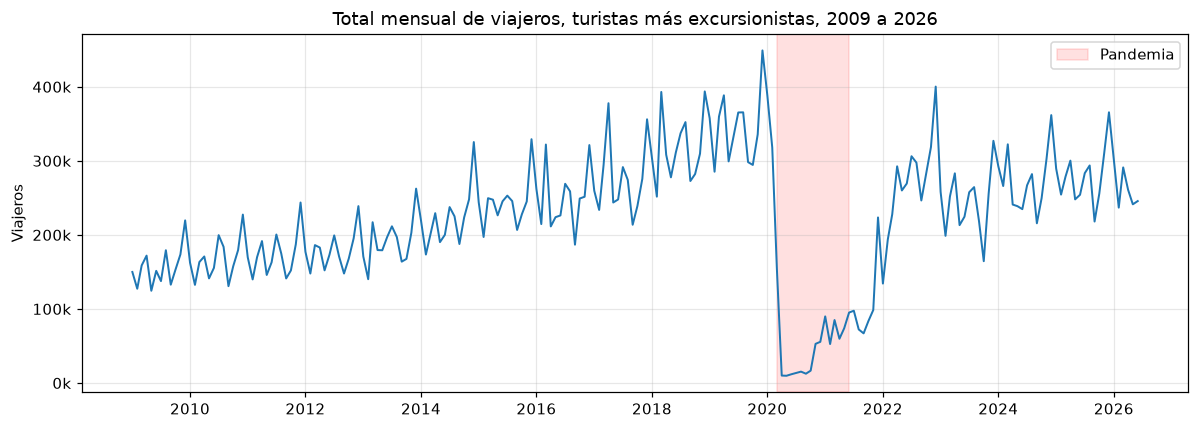

In [38]:
# Comportamiento temporal de la serie total
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(serie.index, serie.values, color="#1f77b4", lw=1.3)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color="red", alpha=.12, label="Pandemia")
ax.set_title("Total mensual de viajeros, turistas más excursionistas, 2009 a 2026")
ax.set_ylabel("Viajeros"); ax.yaxis.set_major_formatter(kfmt); ax.legend()
fig.tight_layout(); fig.savefig(figpath("Total mensual de viajeros"), bbox_inches="tight")

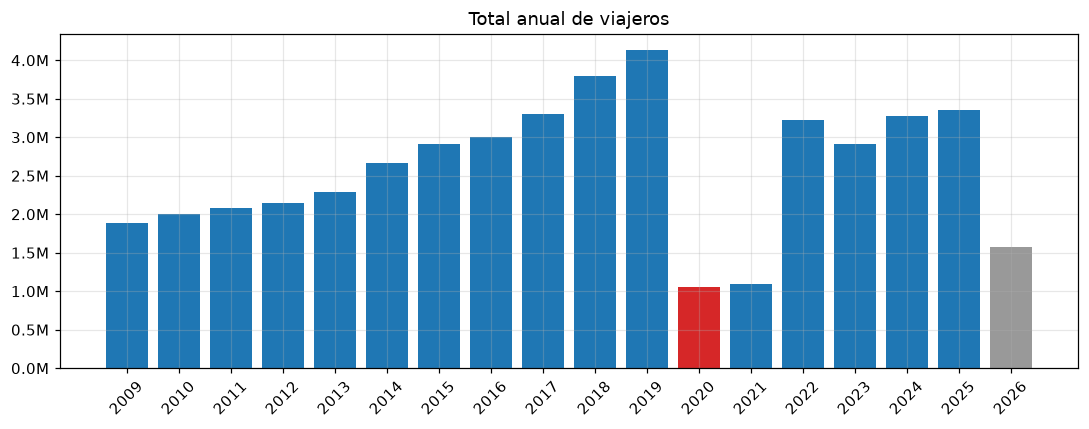

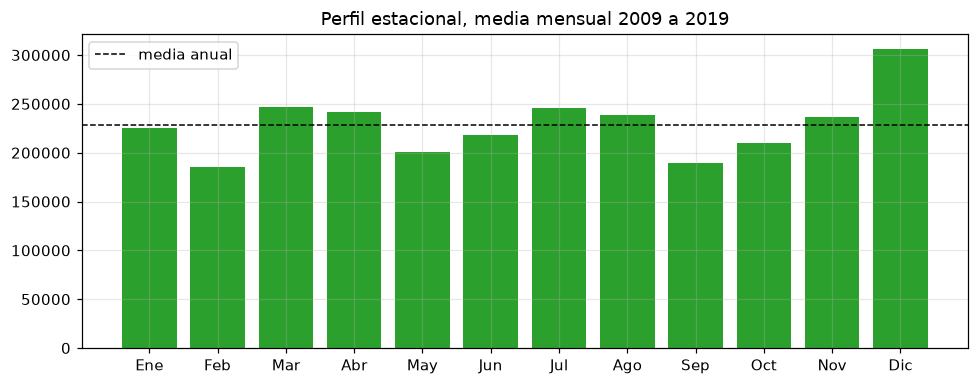

In [39]:
# Total anual con la caída de 2020 y el año parcial 2026 resaltados
anual = te.groupby("Año")["Viajero"].sum()
fig, ax = plt.subplots(figsize=(10,4))
colores = ["#1f77b4"]*len(anual)
colores[anual.index.get_loc(2020)] = "#d62728"
colores[-1] = "#999999"
ax.bar(anual.index.astype(str), anual.values, color=colores)
ax.set_title("Total anual de viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x/1e6:.1f}M"))
plt.xticks(rotation=45)
fig.tight_layout(); fig.savefig(figpath("Total anual de viajeros"), bbox_inches="tight")

# Perfil estacional promedio del periodo anterior a la pandemia
pre = serie[serie.index < "2020-01-01"]
promedio_mes = pre.groupby(pre.index.month).mean()
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
fig, ax = plt.subplots(figsize=(9,3.6))
ax.bar(meses, promedio_mes.values, color="#2ca02c")
ax.axhline(promedio_mes.mean(), ls="--", color="k", lw=1, label="media anual")
ax.set_title("Perfil estacional, media mensual 2009 a 2019"); ax.legend()
fig.tight_layout(); fig.savefig(figpath("Perfil estacional mensual"), bbox_inches="tight")


Top países en millones


,Millones
País,
El Salvador,16.21
Guatemala,14.79
Estados Unidos de América,7.05
Honduras,2.79
México,1.81
Belice,1.33
Nicaragua,1.16



Región dos en millones


,Millones
Región dos,
América Del Centro,37.41
América Del Norte,9.38
Europa,2.22
América Del Sur y el Caribe,1.45
Cruceristas,1.08
Asia,0.42
Oceanía,0.14



Vía en millones


,Millones
Vía,
Terrestre,32.00
Aérea,19.06
Marítima,1.23



Fronteras en millones


,Millones
Frontera,
01 La Aurora,19.03
07 Valle Nuevo,10.73
09 San Cristóbal,5.36
08 Pedro de Alvarado,4.39
10 La Ermita (Nueva Anguiatú),2.88
20 Melchor de Mencos,2.35
13 El Cinchado / El Corinto,1.50


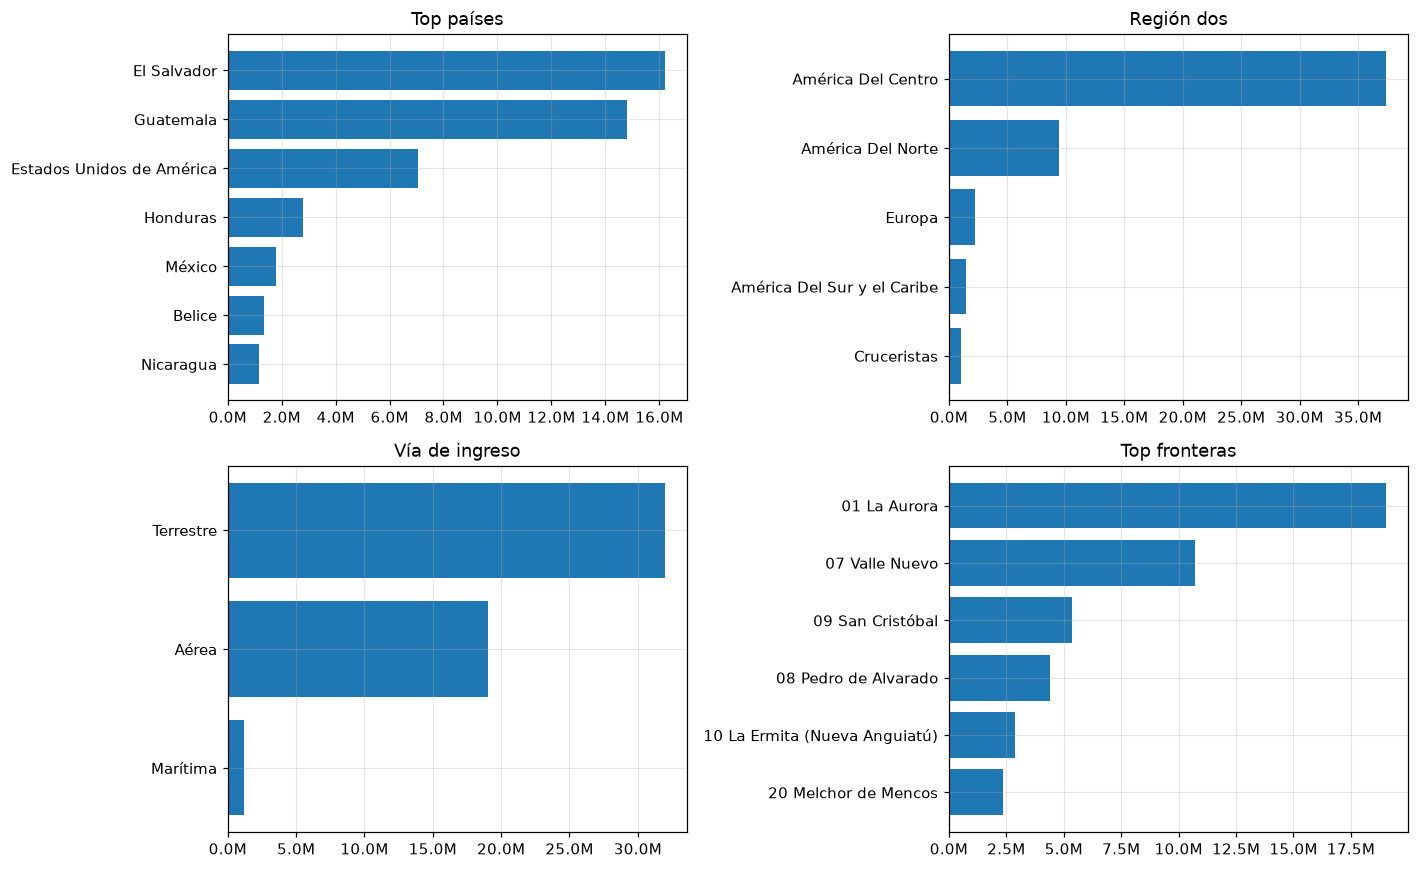

In [40]:
# Rankings por total acumulado de viajeros
fig, axs = plt.subplots(2, 2, figsize=(13,8))

# Dibuja un ranking horizontal ordenado de mayor a menor
def barra_horizontal(ax, s, titulo, div=1e6, fmt="{:.1f}M"):
    s = s.sort_values()
    ax.barh(s.index.astype(str), s.values, color="#1f77b4")
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:fmt.format(x/div)))

barra_horizontal(axs[0,0], df.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(7), "Top países")
barra_horizontal(axs[0,1], df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False).head(5), "Región dos")
barra_horizontal(axs[1,0], df.groupby("Vía")["Viajero"].sum(), "Vía de ingreso")
barra_horizontal(axs[1,1], df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False).head(6), "Top fronteras")
fig.tight_layout(); fig.savefig(figpath("Rankings de países, región, vía y fronteras"), bbox_inches="tight")

# Tablas de volumen acumulado en millones
for col, titulo in [("País","Top países"), ("Región dos","Región dos"), ("Vía","Vía"), ("Frontera","Fronteras")]:
    print(f"\n{titulo} en millones")
    display((df.groupby(col)["Viajero"].sum().sort_values(ascending=False).head(7)/1e6).round(2).to_frame("Millones"))

## Ejercicios 2 y 3 – Partición de datos y construcción de series

El conjunto se divide de forma cronológica en 70% de entrenamiento y 30% de prueba. A partir del conjunto completo se construyen siete series mensuales, la serie total obligatoria formada por turistas y excursionistas, las tres vías de ingreso y las tres regiones con mayor volumen acumulado. Las series por vía y por región usan el total de todos los tipos de viajero para no perder la vía marítima, que corresponde casi por completo a cruceristas.

In [41]:
# ------------------------------------------------------------
# Construcción de las siete series mensuales y partición 70 30
# ------------------------------------------------------------
df = pd.read_parquet("../data/processed/migracion_clean.parquet")

# Serie total obligatoria con la medida consistente
def serie_total(d):
    t = d[d["Tipo de Viajero"].isin(["Turista","Excursionista"])]
    return t.groupby("fecha")["Viajero"].sum().asfreq("MS")

# Serie por categoría con el total de todos los tipos de viajero
def serie_filtro(d, col, val):
    return d[d[col]==val].groupby("fecha")["Viajero"].sum().asfreq("MS").fillna(0)

series = {"Total": serie_total(df)}
for v in ["Aérea","Terrestre","Marítima"]:
    series[f"Via_{v}"] = serie_filtro(df, "Vía", v)
for r in ["América Del Centro","América Del Norte","Europa"]:
    series[f"Reg_{r}"] = serie_filtro(df, "Región dos", r)

mat = pd.DataFrame(series)
n = len(mat)
k = int(round(n*0.70))
train, test = mat.iloc[:k], mat.iloc[k:]
print(f"Total meses {n}, entrenamiento {k}, prueba {n-k}")
print("Entrenamiento:", mat.index[0].date(), "a", mat.index[k-1].date())
print("Prueba:", mat.index[k].date(), "a", mat.index[-1].date())

mat.to_parquet("../data/processed/series_mensuales.parquet")
pd.Series({"k_train": k}).to_json("../data/processed/split.json")

Total meses 210, entrenamiento 147, prueba 63
Entrenamiento: 2009-01-01 a 2021-03-01
Prueba: 2021-04-01 a 2026-06-01


In [42]:
# Inicio, fin y frecuencia de cada serie
resumen = [{"Serie": c,
            "Inicio": mat[c].index.min().date(),
            "Fin": mat[c].index.max().date(),
            "Frecuencia": "Mensual MS",
            "n": len(mat),
            "Media_train": round(train[c].mean())} for c in mat.columns]
display(pd.DataFrame(resumen))

,Serie,Inicio,Fin,Frecuencia,n,Media_train
0,Total,2009-01-01,2026-06-01,Mensual MS,210,214218
1,Via_Aérea,2009-01-01,2026-06-01,Mensual MS,210,89141
2,Via_Terrestre,2009-01-01,2026-06-01,Mensual MS,210,139988
3,Via_Marítima,2009-01-01,2026-06-01,Mensual MS,210,7991
4,Reg_América Del Centro,2009-01-01,2026-06-01,Mensual MS,210,171622
5,Reg_América Del Norte,2009-01-01,2026-06-01,Mensual MS,210,39235
6,Reg_Europa,2009-01-01,2026-06-01,Mensual MS,210,9877


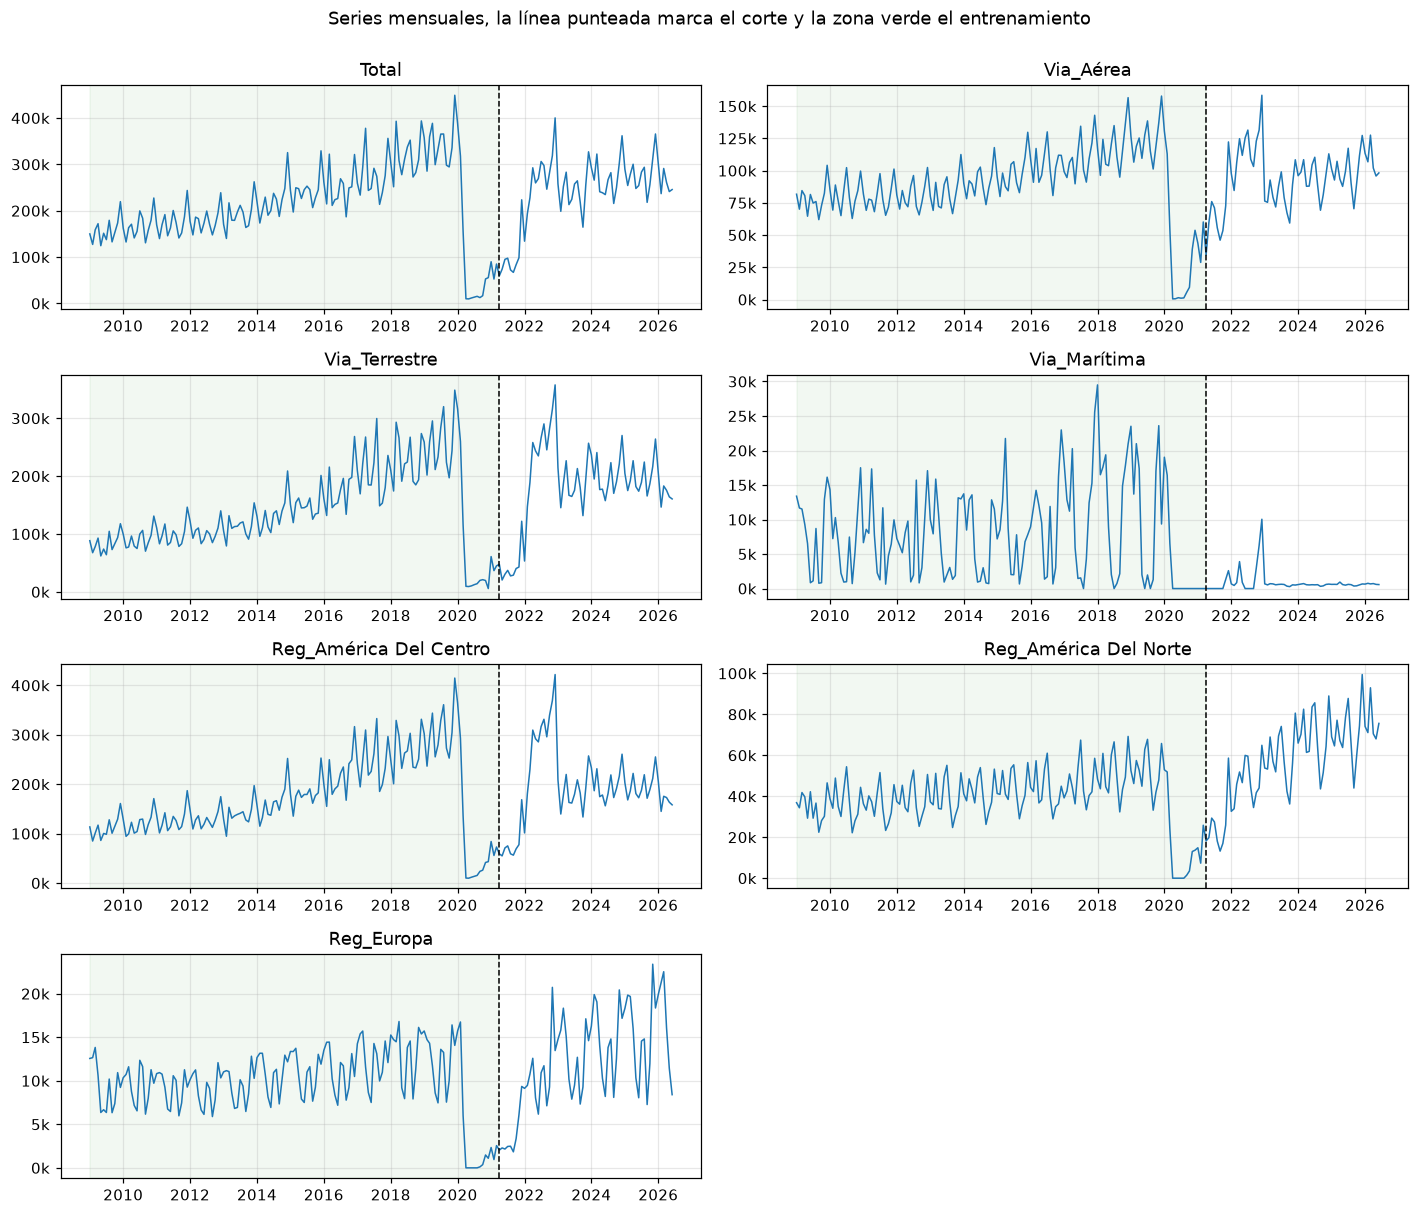

In [43]:
# Panel de las siete series con la marca del corte entre entrenamiento y prueba
corte = mat.index[k]
fig, axs = plt.subplots(4, 2, figsize=(13,11)); axs = axs.ravel()
for ax, name in zip(axs, mat.columns):
    s = mat[name]
    ax.plot(s.index, s.values, lw=1)
    ax.axvline(corte, color="k", ls="--", lw=1)
    ax.axvspan(s.index[0], corte, color="green", alpha=.05)
    ax.set_title(name)
    ax.yaxis.set_major_formatter(kfmt)
axs[-1].axis("off")
fig.suptitle("Series mensuales, la línea punteada marca el corte y la zona verde el entrenamiento", y=1.0)
fig.tight_layout(); fig.savefig(figpath("Panel de las siete series con corte de entrenamiento y prueba"), bbox_inches="tight")

## Ejercicio 4 – Análisis de estacionariedad

Para cada serie se descompone la señal en tendencia, estacionalidad y residuo, y se evalúa la estacionariedad en media y en varianza. Se aplica una transformación logarítmica a las series con varianza no estacionaria y se determina el número de diferencias necesarias mediante la función de autocorrelación, la función de autocorrelación parcial y la prueba de Dickey-Fuller aumentada.

In [44]:
# ------------------------------------------------------------
# Herramientas de estacionariedad
# ------------------------------------------------------------
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

mat = pd.read_parquet("../data/processed/series_mensuales.parquet")
k = int(pd.read_json("../data/processed/split.json", typ="series")["k_train"])

# Series con varianza no estacionaria que se modelan en escala logarítmica
USAR_LOG = {"Via_Aérea": True, "Via_Marítima": True, "Reg_Europa": True}

# Devuelve el valor p de la prueba de Dickey-Fuller aumentada
def adf_p(x):
    x = pd.Series(x).dropna()
    return adfuller(x, autolag="AIC")[1] if len(x) > 10 else np.nan

# Determina el número de diferencias regulares según el valor p de la prueba
def analizar(s, nombre, log=False):
    tr = s.iloc[:k].astype(float)
    x = np.log1p(tr) if log else tr
    p0, p1, p2 = adf_p(x), adf_p(x.diff()), adf_p(x.diff().diff())
    d = 0 if p0 < 0.05 else (1 if p1 < 0.05 else 2)
    print(f"[{nombre:22s}] log={log} nivel={p0:.3f} d1={p1:.3f} d2={p2:.3f} d={d}")
    return d

In [45]:
# Descomposición aditiva de cada serie de entrenamiento
for name in mat.columns:
    s = mat[name].iloc[:k]
    dec = seasonal_decompose(s, model="additive", period=12)
    fig = dec.plot(); fig.set_size_inches(9, 6.5)
    fig.suptitle(f"Descomposición de {name}", y=1.01)
    fig.tight_layout(); fig.savefig(figpath(f"Descomposición de {name}"), bbox_inches="tight"); plt.close(fig)
print("Descomposiciones guardadas")

Descomposiciones guardadas


In [46]:
# Autocorrelación, autocorrelación parcial y número de diferencias por serie
orden = {}
for name in mat.columns:
    s = mat[name]
    log = USAR_LOG.get(name, False)
    d = analizar(s, name, log)
    orden[name] = {"log": log, "d": d}
    # Serie transformada y diferenciada para leer los rezagos significativos
    x = np.log1p(s.iloc[:k]) if log else s.iloc[:k].astype(float)
    for _ in range(d):
        x = x.diff()
    fig, ax = plt.subplots(1, 2, figsize=(12,3.2))
    plot_acf(x.dropna(), lags=36, ax=ax[0])
    plot_pacf(x.dropna(), lags=36, method="ywm", ax=ax[1])
    ax[0].set_title(f"ACF de {name}, d={d}")
    ax[1].set_title(f"PACF de {name}, d={d}")
    fig.tight_layout(); fig.savefig(figpath(f"ACF y PACF de {name}"), bbox_inches="tight"); plt.close(fig)

pd.DataFrame(orden).T.to_json("../data/processed/orden_d.json")
display(pd.DataFrame(orden).T)

[Total                 ] log=False nivel=0.152 d1=0.036 d2=0.000 d=1
[Via_Aérea             ] log=True nivel=0.001 d1=0.019 d2=0.000 d=0
[Via_Terrestre         ] log=False nivel=0.345 d1=0.015 d2=0.000 d=1
[Via_Marítima          ] log=True nivel=1.000 d1=0.575 d2=0.000 d=2
[Reg_América Del Centro] log=False nivel=0.354 d1=0.012 d2=0.000 d=1
[Reg_América Del Norte ] log=False nivel=0.019 d1=0.014 d2=0.000 d=0
[Reg_Europa            ] log=True nivel=0.379 d1=0.047 d2=0.000 d=1


,log,d
Total,False,1
Via_Aérea,True,0
Via_Terrestre,False,1
Via_Marítima,True,2
Reg_América Del Centro,False,1
Reg_América Del Norte,False,0
Reg_Europa,True,1


## Ejercicio 4 – Modelado de las series

Para cada serie se ajustan modelos SARIMA con distintos órdenes seleccionados por el criterio de información de Akaike, un modelo automático con auto_arima, y los modelos Prophet, Holt-Winters, suavizamiento exponencial simple y seasonal naive. Las series con varianza no estacionaria se ajustan en escala logarítmica y se invierten al escalar original. Se analizan los residuos del mejor modelo SARIMA mediante gráficos de diagnóstico y la prueba de Ljung-Box.

In [47]:
# ------------------------------------------------------------
# Ajuste de todos los modelos sobre cada serie
# ------------------------------------------------------------
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import pmdarima as pm
    HAS_PM = True
except Exception:
    HAS_PM = False
try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception:
    HAS_PROPHET = False
print("pmdarima disponible:", HAS_PM, "prophet disponible:", HAS_PROPHET)

mat = pd.read_parquet("../data/processed/series_mensuales.parquet")
k = int(pd.read_json("../data/processed/split.json", typ="series")["k_train"])
_o = pd.read_json("../data/processed/orden_d.json")
D = _o["d"].astype(int).to_dict()
LOG = _o["log"].astype(bool).to_dict()

# Error absoluto medio y raíz del error cuadrático medio
def _met(y, f):
    f = np.asarray(f, dtype=float)
    if not np.isfinite(f).all():
        return np.nan, np.nan
    return mean_absolute_error(y, f), float(np.sqrt(mean_squared_error(y, f)))

# Pronóstico seasonal naive que repite la última temporada observada
def snaive(tr, h, m=12):
    return np.tile(tr.iloc[-m:].values, int(np.ceil(h/m)))[:h]

FORECASTS = {}
METRICS = []
BEST_ARIMA = {}

# Ajusta todos los modelos de una serie y registra sus pronósticos y métricas
def modelar(name):
    s = mat[name].astype(float)
    tr, tst = s.iloc[:k], s.iloc[k:]
    h = len(tst)
    log = LOG.get(name, False)
    d = D[name]
    trm = np.log1p(tr) if log else tr
    inv = np.expm1 if log else (lambda x: x)
    fc = {}
    # Guarda el pronóstico y sus métricas, descartando resultados divergentes
    def registrar(model, f, aic=np.nan, bic=np.nan):
        f = pd.Series(np.asarray(f, dtype=float), index=tst.index)
        if np.isfinite(f).all() and f.abs().max() > 50*tr.abs().max():
            f[:] = np.nan
        fc[model] = f
        mae, rmse = _met(tst.values, f.values)
        METRICS.append((name, model, mae, rmse, aic, bic))
    registrar("SeasonalNaive", snaive(tr, h))
    registrar("SES", inv(SimpleExpSmoothing(trm).fit().forecast(h)))
    try:
        hw = ExponentialSmoothing(trm, trend="add", seasonal="add", seasonal_periods=12).fit()
        registrar("HoltWinters", inv(hw.forecast(h)), hw.aic, hw.bic)
    except Exception:
        registrar("HoltWinters", np.full(h, np.nan))
    # Selección del mejor SARIMA entre varios órdenes por menor AIC
    best = None
    for od, so in [((1,d,1),(0,1,1,12)), ((0,d,1),(0,1,1,12)), ((1,d,0),(1,1,0,12)), ((2,d,2),(1,1,1,12))]:
        try:
            mm = SARIMAX(trm, order=od, seasonal_order=so,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if best is None or mm.aic < best[0]:
                best = (mm.aic, mm.bic, od, so, mm)
        except Exception:
            pass
    if best:
        BEST_ARIMA[name] = (best[2], best[3], best[4])
        registrar(f"SARIMA{best[2]}x{best[3]}", inv(best[4].forecast(h)), best[0], best[1])
    if HAS_PM:
        try:
            am = pm.auto_arima(trm, seasonal=True, m=12, stepwise=True,
                               suppress_warnings=True, error_action="ignore", max_p=3, max_q=3)
            registrar(f"auto_arima{am.order}x{am.seasonal_order}", inv(am.predict(h)), am.aic(), am.bic())
        except Exception:
            pass
    if HAS_PROPHET:
        try:
            p = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
            p.fit(pd.DataFrame({"ds": tr.index, "y": trm.values}))
            yh = p.predict(p.make_future_dataframe(periods=h, freq="MS"))["yhat"].iloc[-h:].values
            registrar("Prophet", inv(yh))
        except Exception:
            pass
    FORECASTS[name] = fc

for name in mat.columns:
    modelar(name)
    print("Modelado:", name)

METRICS = pd.DataFrame(METRICS, columns=["Serie","Modelo","MAE","RMSE","AIC","BIC"])
METRICS.to_csv("../data/processed/metricas_modelos.csv", index=False)
print("Métricas guardadas")

pmdarima disponible: True prophet disponible: True
Modelado: Total
Modelado: Via_Aérea
Modelado: Via_Terrestre
Modelado: Via_Marítima
Modelado: Reg_América Del Centro
Modelado: Reg_América Del Norte
Modelado: Reg_Europa
Métricas guardadas


In [48]:
# Diagnóstico de residuos del mejor SARIMA y prueba de Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox
for name, (od, so, m) in BEST_ARIMA.items():
    fig = m.plot_diagnostics(figsize=(10,7))
    fig.suptitle(f"Diagnóstico de residuos, SARIMA {od} {so}, {name}", y=1.0)
    fig.tight_layout(); fig.savefig(figpath(f"Diagnóstico de residuos de {name}"), bbox_inches="tight"); plt.close(fig)
    lb = acorr_ljungbox(m.resid, lags=[12], return_df=True)
    print(f"{name:24s} SARIMA {od} {so} AIC={m.aic:.0f} Ljung-Box p={lb['lb_pvalue'].iloc[0]:.3f}")

Total                    SARIMA (2, 1, 2) (1, 1, 1, 12) AIC=2880 Ljung-Box p=0.041
Via_Aérea                SARIMA (1, 0, 0) (1, 1, 0, 12) AIC=165 Ljung-Box p=0.000
Via_Terrestre            SARIMA (2, 1, 2) (1, 1, 1, 12) AIC=2849 Ljung-Box p=0.355
Via_Marítima             SARIMA (2, 2, 2) (1, 1, 1, 12) AIC=500 Ljung-Box p=0.020
Reg_América Del Centro   SARIMA (2, 1, 2) (1, 1, 1, 12) AIC=2866 Ljung-Box p=0.497
Reg_América Del Norte    SARIMA (2, 0, 2) (1, 1, 1, 12) AIC=2475 Ljung-Box p=0.000
Reg_Europa               SARIMA (0, 1, 1) (0, 1, 1, 12) AIC=333 Ljung-Box p=0.113


## Ejercicio 4 – Predicción y comparación de métricas

Se selecciona el mejor modelo de cada serie según el menor error cuadrático medio en el conjunto de prueba, se comparan los modelos mediante error absoluto medio, raíz del error cuadrático medio y los criterios AIC y BIC, y se grafica el pronóstico del mejor modelo frente a los valores reales.

In [49]:
# Tabla de métricas por serie y selección del mejor modelo por menor RMSE
mejor = {}
for nm, g in METRICS.groupby("Serie"):
    gg = g.dropna(subset=["RMSE"])
    b = gg.loc[gg["RMSE"].idxmin()]
    mejor[nm] = b["Modelo"]
    print(f"\n{nm}")
    display(g[["Modelo","MAE","RMSE","AIC","BIC"]].round(0).reset_index(drop=True))
print("\nMejor modelo por serie")
display(pd.Series(mejor, name="MejorModelo").to_frame())


Reg_América Del Centro


,Modelo,MAE,RMSE,AIC,BIC
0,SeasonalNaive,160448.0,178314.0,NaN,NaN
1,SES,125408.0,145194.0,NaN,NaN
2,HoltWinters,203719.0,221949.0,3089.0,3137.0
3,"SARIMA(2, 1, 2)x(1, 1, 1, 12)",348865.0,384490.0,2866.0,2885.0
4,"auto_arima(2, 1, 3)x(2, 0, 0, 12)",229145.0,251854.0,3499.0,3523.0
5,Prophet,49330.0,72731.0,NaN,NaN



Reg_América Del Norte


,Modelo,MAE,RMSE,AIC,BIC
0,SeasonalNaive,51060.0,54630.0,NaN,NaN
1,SES,40464.0,45105.0,NaN,NaN
2,HoltWinters,53013.0,57797.0,2583.0,2631.0
3,"SARIMA(2, 0, 2)x(1, 1, 1, 12)",41339.0,45727.0,2475.0,2495.0
4,"auto_arima(2, 0, 2)x(1, 0, 0, 12)",27036.0,30944.0,3073.0,3094.0
5,Prophet,37736.0,42394.0,NaN,NaN



Reg_Europa


...

,Modelo,MAE,RMSE,AIC,BIC
0,SeasonalNaive,858.0,1732.0,NaN,NaN
1,SES,858.0,1732.0,NaN,NaN
2,HoltWinters,859.0,1732.0,192.0,240.0
3,"SARIMA(2, 2, 2)x(1, 1, 1, 12)",859.0,1732.0,500.0,520.0
4,"auto_arima(0, 1, 1)x(2, 0, 0, 12)",859.0,1732.0,602.0,614.0
5,Prophet,784.0,1645.0,NaN,NaN



Via_Terrestre


,Modelo,MAE,RMSE,AIC,BIC
0,SeasonalNaive,160013.0,176653.0,NaN,NaN
1,SES,140730.0,156647.0,NaN,NaN
2,HoltWinters,213203.0,231701.0,3074.0,3122.0
3,"SARIMA(2, 1, 2)x(1, 1, 1, 12)",320224.0,352954.0,2849.0,2868.0
4,"auto_arima(2, 1, 3)x(2, 0, 0, 12)",237693.0,259150.0,3474.0,3497.0
5,Prophet,54280.0,71294.0,NaN,NaN



Mejor modelo por serie


,MejorModelo
Reg_América Del Centro,Prophet
Reg_América Del Norte,"auto_arima(2, 0, 2)x(1, 0, 0, 12)"
Reg_Europa,SES
Total,Prophet
Via_Aérea,"auto_arima(1, 0, 1)x(1, 0, 1, 12)"
Via_Marítima,Prophet
Via_Terrestre,Prophet


In [50]:
# Pronóstico del mejor modelo frente a los valores reales de prueba
for name in mat.columns:
    s = mat[name].astype(float)
    tr, tst = s.iloc[:k], s.iloc[k:]
    f = FORECASTS[name][mejor[name]]
    fig, ax = plt.subplots(figsize=(11,3.6))
    ax.plot(tr.index[-36:], tr.values[-36:], color="#1f77b4", label="entrenamiento")
    ax.plot(tst.index, tst.values, color="k", lw=1.8, label="prueba real")
    ax.plot(f.index, f.values, color="#d62728", ls="--", label=f"pronóstico {mejor[name]}")
    ax.set_title(f"{name}, mejor modelo {mejor[name]}")
    ax.yaxis.set_major_formatter(kfmt); ax.legend()
    fig.tight_layout(); fig.savefig(figpath(f"Pronóstico del mejor modelo de {name}"), bbox_inches="tight"); plt.close(fig)
print("Pronósticos graficados")

Pronósticos graficados


## Ejercicio 5 – Análisis comparativo

Se cuantifica para cada serie la fuerza estacional y de tendencia obtenidas de la descomposición sobre la ventana estable de 2011 a 2019, la tasa de crecimiento anual compuesta del mismo periodo, la volatilidad medida por el coeficiente de variación y el impacto de la pandemia estimado por la caída anual de 2020 respecto a 2019.

In [51]:
# Indicadores comparativos por serie
comp = []
for name in mat.columns:
    s = mat[name].astype(float)
    pre = s[(s.index >= "2011-01-01") & (s.index < "2020-01-01")]
    dec = seasonal_decompose(pre, model="additive", period=12)
    fuerza_estacional = max(0, 1 - dec.resid.var()/(dec.seasonal + dec.resid).var())
    fuerza_tendencia = max(0, 1 - dec.resid.var()/(dec.trend.dropna() + dec.resid.dropna()).var())
    anual_s = s.resample("YE").sum()
    cagr = (anual_s.loc["2019-12-31"]/anual_s.loc["2011-12-31"])**(1/8) - 1
    cv = s.std()/s.mean()
    caida = (anual_s.loc["2020-12-31"] - anual_s.loc["2019-12-31"])/anual_s.loc["2019-12-31"]
    comp.append({"Serie": name, "FuerzaEstacional": fuerza_estacional,
                 "FuerzaTendencia": fuerza_tendencia, "CAGR_11_19": cagr,
                 "CV": cv, "Caida2020": caida})
comp = pd.DataFrame(comp).set_index("Serie")
display(comp.round(3))

# Resalta el líder de cada indicador dentro de un grupo de series
def resaltar(grupo, titulo):
    sub = comp.loc[grupo]
    print(f"\n{titulo}")
    print("Mayor estacionalidad:", sub["FuerzaEstacional"].idxmax())
    print("Mayor tendencia:", sub["CAGR_11_19"].idxmax(), f"{sub['CAGR_11_19'].max():.1%}")
    print("Mayor volatilidad:", sub["CV"].idxmax(), f"{sub['CV'].max():.2f}")
    print("Más afectada por la pandemia:", sub["Caida2020"].idxmin(), f"{sub['Caida2020'].min():.1%}")

resaltar(["Via_Aérea","Via_Terrestre","Via_Marítima"], "Categoría vías de ingreso")
resaltar(["Reg_América Del Centro","Reg_América Del Norte","Reg_Europa"], "Categoría regiones")

,FuerzaEstacional,FuerzaTendencia,CAGR_11_19,CV,Caida2020
Serie,,,,,
Total,0.743,0.890,0.090,0.381,-0.744
Via_Aérea,0.894,0.922,0.056,0.305,-0.723
Via_Terrestre,0.619,0.877,0.126,0.493,-0.736
Via_Marítima,0.688,0.278,0.055,1.147,-0.679
Reg_América Del Centro,0.665,0.900,0.115,0.452,-0.729
Reg_América Del Norte,0.945,0.830,0.047,0.408,-0.742
Reg_Europa,0.894,0.740,0.038,0.435,-0.718



Categoría vías de ingreso
Mayor estacionalidad: Via_Aérea
Mayor tendencia: Via_Terrestre 12.6%
Mayor volatilidad: Via_Marítima 1.15
Más afectada por la pandemia: Via_Terrestre -73.6%

Categoría regiones
Mayor estacionalidad: Reg_América Del Norte
Mayor tendencia: Reg_América Del Centro 11.5%
Mayor volatilidad: Reg_América Del Centro 0.45
Más afectada por la pandemia: Reg_América Del Norte -74.2%


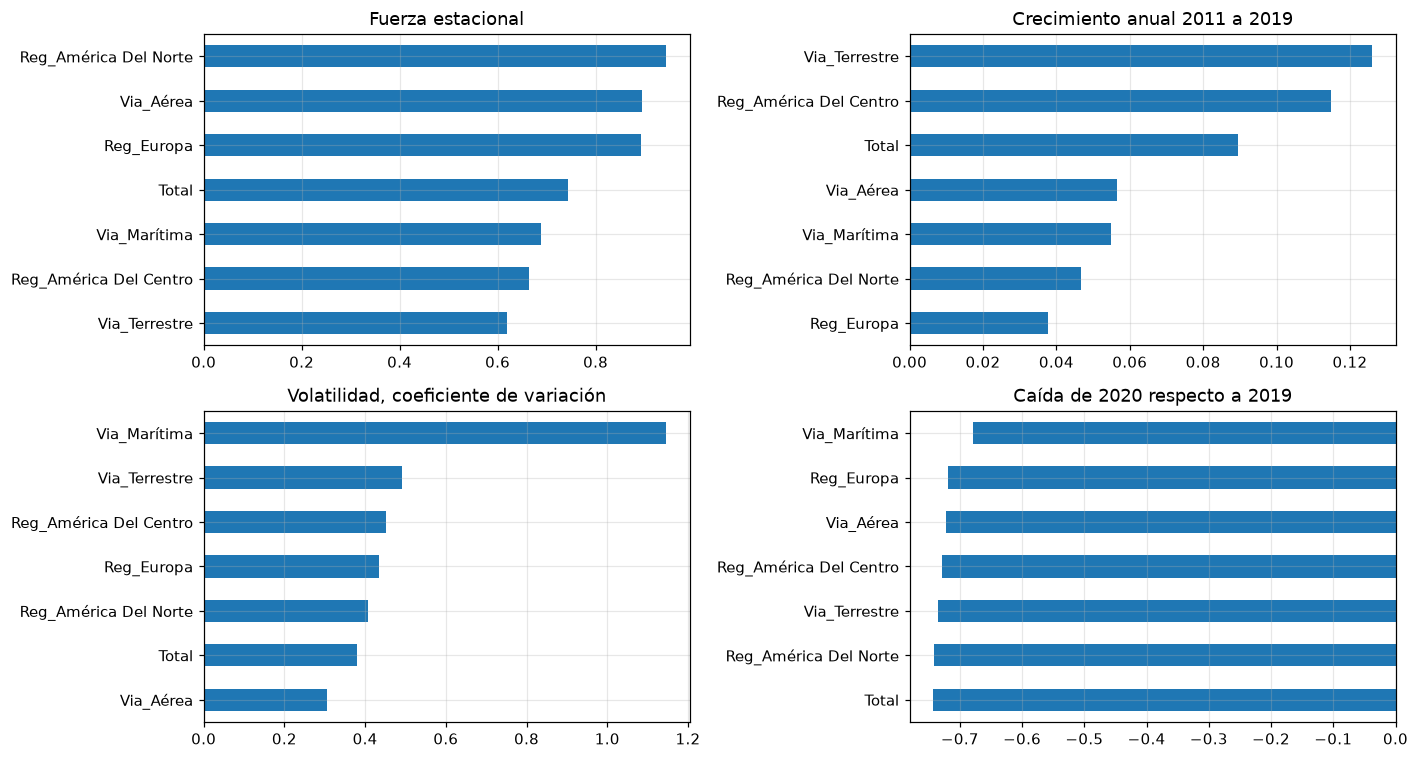

In [52]:
# Comparación visual de los cuatro indicadores
fig, axs = plt.subplots(2, 2, figsize=(13,7)); axs = axs.ravel()
indicadores = [("FuerzaEstacional","Fuerza estacional"), ("CAGR_11_19","Crecimiento anual 2011 a 2019"),
               ("CV","Volatilidad, coeficiente de variación"), ("Caida2020","Caída de 2020 respecto a 2019")]
for ax, (colm, tit) in zip(axs, indicadores):
    comp[colm].sort_values().plot.barh(ax=ax, color="#1f77b4")
    ax.set_title(tit); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(figpath("Comparación de indicadores por serie"), bbox_inches="tight")

In [53]:
# Guarda el índice de figuras para referenciarlas en el informe
idx = pd.DataFrame(FIG_INDEX, columns=["Figura","Descripción"])
idx["Archivo"] = idx["Figura"].map(lambda i: f"Figura{i}.png")
idx.to_csv("../figures/indice_figuras.csv", index=False)
print("Total de figuras generadas:", FIGN)
display(idx)

Total de figuras generadas: 34


,Figura,Descripción,Archivo
0,1,Total mensual de viajeros,Figura1.png
1,2,Total anual de viajeros,Figura2.png
2,3,Perfil estacional mensual,Figura3.png
3,4,"Rankings de países, región, vía y fronteras",Figura4.png
4,5,Panel de las siete series con corte de entrena...,Figura5.png
5,6,Descomposición de Total,Figura6.png
6,7,Descomposición de Via_Aérea,Figura7.png
7,8,Descomposición de Via_Terrestre,Figura8.png
8,9,Descomposición de Via_Marítima,Figura9.png
9,10,Descomposición de Reg_América Del Centro,Figura10.png


## Conclusiones

Los modelos SARIMA obtienen los mejores valores de AIC y BIC, es decir el mejor ajuste dentro de la muestra, pero producen el mayor error en el conjunto de prueba. Esto ocurre porque el entrenamiento termina en marzo de 2021, en plena pandemia, de modo que estos modelos proyectan el nivel deprimido y la estacionalidad del confinamiento. Los modelos Prophet, suavizamiento exponencial simple y auto_arima generalizan mejor sobre el periodo de recuperación y obtienen el menor error según la serie. Este resultado muestra que los criterios AIC y BIC no bastan para elegir un modelo de pronóstico cuando existe un quiebre estructural en la frontera entre entrenamiento y prueba.

En la categoría de vías de ingreso, la vía aérea presenta la mayor estacionalidad, la vía terrestre la mayor tendencia de crecimiento con una tasa anual cercana al 12.6 por ciento, la vía marítima la mayor volatilidad por el carácter esporádico de los cruceros, y la vía terrestre fue la más afectada por la pandemia con una caída anual del 73.6 por ciento. En la categoría de regiones, América del Norte muestra la mayor estacionalidad, América del Centro la mayor tendencia de crecimiento y también la mayor volatilidad, y América del Norte fue la más afectada por la pandemia con una caída del 74.2 por ciento.

Para el INGUAT los hallazgos más útiles son los siguientes. La estacionalidad es muy marcada, con un máximo en diciembre y un mínimo en febrero, lo que permite planificar capacidad y campañas por temporada. La recuperación posterior a 2021 superó el promedio del periodo de entrenamiento y estuvo impulsada por el turismo terrestre regional. La vía marítima es la de menor volumen y mayor volatilidad, por lo que representa un nicho de alto riesgo y alta oportunidad. Los modelos flexibles como Prophet resultan preferibles para el pronóstico operativo después de choques como la pandemia.